# Analisis Sentimen Pelanggan E-Commerce Menggunakan PySpark

Notebook ini digunakan untuk mengerjakan final project mata kuliah **Artificial Intelligence dan Big Data** dengan studi kasus **Analisis Sentimen Pelanggan E-Commerce**.

Dataset yang digunakan adalah **Amazon Reviews for Sentiment Analysis** dengan format label:

- `__label__1` = sentimen negatif
- `__label__2` = sentimen positif

Alur pengerjaan:

1. Inisialisasi environment dan Spark.
2. Membaca dataset mentah `.bz2`.
3. Parsing label dan teks review.
4. Cleaning teks.
5. Menyimpan data bersih ke format Parquet.
6. Tokenization dan stopword removal.
7. Ekstraksi fitur menggunakan TF-IDF.
8. Training model Logistic Regression.
9. Evaluasi model.
10. Menyimpan metrik dan visualisasi.

## 1. Import Library dan Konfigurasi Path

Bagian ini menyiapkan library utama dan path folder project.  
Kode dibuat fleksibel agar notebook tetap bisa dijalankan dari folder root project maupun dari folder `notebooks/`.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_extract, regexp_replace, trim, lower, when, length
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.classification import LinearSVC
from pyspark.ml.classification import RandomForestClassifier

In [2]:
# Deteksi root project secara otomatis.
# Jika notebook dijalankan dari folder notebooks/, root project adalah parent folder.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

# Membuat folder output jika belum ada.
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_RAW_PATH = DATA_RAW_DIR / "train.ft.txt.bz2"
TEST_RAW_PATH = DATA_RAW_DIR / "test.ft.txt.bz2"

TRAIN_CLEAN_PATH = DATA_PROCESSED_DIR / "train_clean.parquet"
TEST_CLEAN_PATH = DATA_PROCESSED_DIR / "test_clean.parquet"

print("Project root       :", PROJECT_ROOT)
print("Train raw path     :", TRAIN_RAW_PATH)
print("Test raw path      :", TEST_RAW_PATH)
print("Processed data dir :", DATA_PROCESSED_DIR)

Project root       : d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis
Train raw path     : d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\data\raw\train.ft.txt.bz2
Test raw path      : d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\data\raw\test.ft.txt.bz2
Processed data dir : d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\data\processed


## 2. Inisialisasi Spark Session

Konfigurasi Spark disesuaikan untuk perangkat lokal **MacBook Pro M2 Pro 16 GB RAM**.  
Spark dijalankan dalam mode lokal dengan beberapa core CPU dan alokasi memori yang cukup untuk membaca serta memproses dataset besar.

Catatan: PySpark standar berjalan dominan di CPU dan RAM, bukan GPU.

In [3]:
spark = (
    SparkSession.builder
    .appName("Amazon Review Sentiment Analysis Full Dataset")
    .master("local[6]")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "48")
    .config("spark.default.parallelism", "48")
    .config("spark.sql.files.maxPartitionBytes", "64m")
    .config("spark.memory.fraction", "0.6")
    .config("spark.memory.storageFraction", "0.3")
    .getOrCreate()
)

spark

## 3. Membaca Dataset Mentah

Dataset mentah masih berupa file teks terkompresi `.bz2`.  
Setiap baris berisi label dan teks review dalam format berikut:

```text
__label__2 This product is very good
__label__1 This product is disappointing
```

In [4]:
train_raw = spark.read.text(str(TRAIN_RAW_PATH))
test_raw = spark.read.text(str(TEST_RAW_PATH))

print("Jumlah data train mentah:", train_raw.count())
print("Jumlah data test mentah :", test_raw.count())

train_raw.show(5, truncate=120)

Jumlah data train mentah: 3600000
Jumlah data test mentah : 400000
+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                   value|
+------------------------------------------------------------------------------------------------------------------------+
|__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well ...|
|__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game sou...|
|__label__2 Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of "Prisoners ...|
|__label__2 Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played this game a...|
|__label__2 Remember, Pull Your Jaw Off The Floor After Hearing it: If y

## 4. Parsing Label dan Review

Pada tahap ini, label dipisahkan dari teks review.

Mapping label:

| Label Asli | Label Numerik | Sentimen |
|---|---:|---|
| `__label__1` | 0 | Negatif |
| `__label__2` | 1 | Positif |

In [5]:
def parse_review_dataframe(raw_df):
    parsed_df = raw_df.select(
        regexp_extract(col("value"), r"^(__label__\d)", 1).alias("raw_label"),
        trim(regexp_replace(col("value"), r"^__label__\d\s+", "")).alias("review")
    )

    parsed_df = parsed_df.withColumn(
        "label",
        when(col("raw_label") == "__label__1", 0).otherwise(1)
    )

    return parsed_df

train_df = parse_review_dataframe(train_raw)
test_df = parse_review_dataframe(test_raw)

train_df.select("raw_label", "label", "review").show(5, truncate=100)

+----------+-----+----------------------------------------------------------------------------------------------------+
| raw_label|label|                                                                                              review|
+----------+-----+----------------------------------------------------------------------------------------------------+
|__label__2|    1|Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind...|
|__label__2|    1|The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best ...|
|__label__2|    1|Amazing!: This soundtrack is my favorite music of all time, hands down. The intense sadness of "P...|
|__label__2|    1|Excellent Soundtrack: I truly like this soundtrack and I enjoy video game music. I have played th...|
|__label__2|    1|Remember, Pull Your Jaw Off The Floor After Hearing it: If you've played the game, you know how d...|
+----------+-----+----------------------

## 5. Eksplorasi Data Awal

Eksplorasi dilakukan untuk mengetahui distribusi label dan karakteristik panjang review sebelum preprocessing.

In [6]:
print("Distribusi label train:")
train_df.groupBy("raw_label", "label").count().show()

print("Distribusi label test:")
test_df.groupBy("raw_label", "label").count().show()

Distribusi label train:
+----------+-----+-------+
| raw_label|label|  count|
+----------+-----+-------+
|__label__2|    1|1800000|
|__label__1|    0|1800000|
+----------+-----+-------+

Distribusi label test:
+----------+-----+------+
| raw_label|label| count|
+----------+-----+------+
|__label__2|    1|200000|
|__label__1|    0|200000|
+----------+-----+------+



In [7]:
train_df = train_df.withColumn("review_length", length(col("review")))
test_df = test_df.withColumn("review_length", length(col("review")))

print("Statistik panjang review train:")
train_df.select("review_length").describe().show()

print("Statistik panjang review test:")
test_df.select("review_length").describe().show()

Statistik panjang review train:
+-------+------------------+
|summary|     review_length|
+-------+------------------+
|  count|           3600000|
|   mean| 431.6463147222222|
| stddev|237.55257109885272|
|    min|                72|
|    max|              1015|
+-------+------------------+

Statistik panjang review test:
+-------+------------------+
|summary|     review_length|
+-------+------------------+
|  count|            400000|
|   mean|         431.42963|
| stddev|237.43538279280463|
|    min|                99|
|    max|              1015|
+-------+------------------+



## 6. Cleaning Teks

Tahap cleaning dilakukan agar teks lebih konsisten sebelum masuk ke proses feature extraction.

Cleaning yang dilakukan:

1. Mengubah teks menjadi huruf kecil.
2. Menghapus URL.
3. Menghapus karakter selain huruf.
4. Menghapus spasi berlebih.
5. Menghapus data yang kosong setelah cleaning.

In [8]:
def clean_review_dataframe(df):
    clean_df = df.withColumn("clean_review", lower(col("review")))
    clean_df = clean_df.withColumn("clean_review", regexp_replace(col("clean_review"), r"http\S+|www\S+", ""))
    clean_df = clean_df.withColumn("clean_review", regexp_replace(col("clean_review"), r"[^a-z\s]", " "))
    clean_df = clean_df.withColumn("clean_review", regexp_replace(col("clean_review"), r"\s+", " "))
    clean_df = clean_df.withColumn("clean_review", trim(col("clean_review")))

    clean_df = clean_df.filter(
        (col("clean_review").isNotNull()) & (trim(col("clean_review")) != "")
    )

    return clean_df.select("label", "clean_review")

train_clean = clean_review_dataframe(train_df)
test_clean = clean_review_dataframe(test_df)

print("Jumlah data train setelah cleaning:", train_clean.count())
print("Jumlah data test setelah cleaning :", test_clean.count())

train_clean.show(5, truncate=100)

Jumlah data train setelah cleaning: 3599988
Jumlah data test setelah cleaning : 399999
+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                        clean_review|
+-----+----------------------------------------------------------------------------------------------------+
|    1|stuning even for the non gamer this sound track was beautiful it paints the senery in your mind s...|
|    1|the best soundtrack ever to anything i m reading a lot of reviews saying that this is the best ga...|
|    1|amazing this soundtrack is my favorite music of all time hands down the intense sadness of prison...|
|    1|excellent soundtrack i truly like this soundtrack and i enjoy video game music i have played this...|
|    1|remember pull your jaw off the floor after hearing it if you ve played the game you know how divi...|
+-----+----------------------------------

## 7. Menyimpan Data Bersih ke Parquet

Data bersih disimpan ke format **Parquet** agar proses berikutnya lebih efisien.  
Parquet cocok digunakan dalam ekosistem Spark karena bersifat kolumnar dan lebih cepat dibaca dibanding file teks mentah.

Jumlah partisi:

- Train: 64 partisi
- Test: 16 partisi

In [9]:
train_clean.repartition(64).write.mode("overwrite").parquet(str(TRAIN_CLEAN_PATH))
test_clean.repartition(16).write.mode("overwrite").parquet(str(TEST_CLEAN_PATH))

print("Data train bersih disimpan ke:", TRAIN_CLEAN_PATH)
print("Data test bersih disimpan ke :", TEST_CLEAN_PATH)

Data train bersih disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\data\processed\train_clean.parquet
Data test bersih disimpan ke : d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\data\processed\test_clean.parquet


## 8. Verifikasi Data Parquet

Setelah data disimpan, data dibaca ulang untuk memastikan file Parquet berhasil dibuat dan dapat digunakan.

In [10]:
train_parquet = spark.read.parquet(str(TRAIN_CLEAN_PATH))
test_parquet = spark.read.parquet(str(TEST_CLEAN_PATH))

print("Jumlah data train parquet:", train_parquet.count())
print("Jumlah data test parquet :", test_parquet.count())

train_parquet.printSchema()
train_parquet.show(5, truncate=100)

Jumlah data train parquet: 3599988
Jumlah data test parquet : 399999
root
 |-- label: integer (nullable = true)
 |-- clean_review: string (nullable = true)

+-----+----------------------------------------------------------------------------------------------------+
|label|                                                                                        clean_review|
+-----+----------------------------------------------------------------------------------------------------+
|    0|not all there for anyone thinking they are getting all the halloween movies up to this point be v...|
|    1|i can t get enough of this garbage another collection of the hypnotic shirley manson tunes this a...|
|    1|one of my all time favorite books back in print a dog eared copy of this book was read over and o...|
|    0|complicated i still haven t figured out how to put this light together when i do the wires appear...|
|    0|did the job then it died even tho the seller shipped me a used one instea

In [11]:
print("Distribusi label train setelah cleaning:")
train_parquet.groupBy("label").count().show()

print("Distribusi label test setelah cleaning:")
test_parquet.groupBy("label").count().show()

Distribusi label train setelah cleaning:
+-----+-------+
|label|  count|
+-----+-------+
|    0|1799997|
|    1|1799991|
+-----+-------+

Distribusi label test setelah cleaning:
+-----+------+
|label| count|
+-----+------+
|    0|200000|
|    1|199999|
+-----+------+



## 9. Tokenization dan Stopword Removal

Tahap ini mengubah teks menjadi kumpulan token/kata, lalu menghapus stopword bahasa Inggris seperti `the`, `is`, `and`, dan sebagainya.

In [12]:
tokenizer = Tokenizer(
    inputCol="clean_review",
    outputCol="words"
)

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    locale="en_US"
)

train_tokenized = tokenizer.transform(train_parquet)
test_tokenized = tokenizer.transform(test_parquet)

train_filtered = remover.transform(train_tokenized)
test_filtered = remover.transform(test_tokenized)

train_filtered.select("label", "clean_review", "filtered_words").show(5, truncate=100)

+-----+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|label|                                                                                        clean_review|                                                                                      filtered_words|
+-----+----------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------+
|    0|not all there for anyone thinking they are getting all the halloween movies up to this point be v...|[anyone, thinking, getting, halloween, movies, point, clear, overpriced, release, includes, hallo...|
|    1|i can t get enough of this garbage another collection of the hypnotic shirley manson tunes this a...|[get, enough, garbage, another, collection, hypnotic

## 10. Ekstraksi Fitur TF-IDF

Model machine learning tidak dapat membaca teks mentah secara langsung.  
Karena itu, teks diubah menjadi vektor numerik menggunakan pendekatan **TF-IDF**.

Pada notebook ini digunakan:

- `HashingTF` untuk mengubah token menjadi vektor frekuensi.
- `IDF` untuk memberi bobot lebih tinggi pada kata yang lebih informatif.
- `numFeatures = 20000` sebagai jumlah dimensi fitur.

In [13]:
hashing_tf = HashingTF(
    inputCol="filtered_words",
    outputCol="raw_features",
    numFeatures=20000
)

train_tf = hashing_tf.transform(train_filtered)
test_tf = hashing_tf.transform(test_filtered)

idf = IDF(
    inputCol="raw_features",
    outputCol="features"
)

idf_model = idf.fit(train_tf)

train_features = idf_model.transform(train_tf).select("label", "features")
test_features = idf_model.transform(test_tf).select("label", "features")

train_features.show(5, truncate=False)

+-----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|features                                                   

## 11. Training Model

Model yang dilatih pada tahap ini mencakup empat algoritma: **Logistic Regression**, **Naive Bayes**, **SVM (LinearSVC)**, dan **Random Forest**. Keempatnya menggunakan fitur TF-IDF yang sama sebagai input untuk kemudian dibandingkan performanya.

In [14]:
# Training Model Logistic Regression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_features)
print("Training Logistic Regression selesai.")

Training Logistic Regression selesai.


In [15]:
# Training Model Naive Bayes

nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=1.0,
    modelType="multinomial"
)

nb_model = nb.fit(train_features)
print("Training Naive Bayes selesai.")

Training Naive Bayes selesai.


In [16]:
# Training Model SVM (Linear SVC)

svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.01
)

svm_model = svm.fit(train_features)
print("Training SVM (LinearSVC) selesai.")

Training SVM (LinearSVC) selesai.


In [17]:
# Training Model Random Forest

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_features)
print("Training Random Forest selesai.")

Training Random Forest selesai.


## 12. Prediksi Data Test

Model yang sudah dilatih digunakan untuk memprediksi sentimen pada data test.

In [18]:
predictions_lr  = lr_model.transform(test_features)
predictions_nb  = nb_model.transform(test_features)
predictions_svm = svm_model.transform(test_features)
predictions_rf  = rf_model.transform(test_features)

model_predictions = {
    "Logistic Regression": (predictions_lr,  "probability"),
    "Naive Bayes":         (predictions_nb,  "probability"),
    "Random Forest":       (predictions_rf,  "probability"),
    "SVM (LinearSVC)":     (predictions_svm, "rawPrediction"),  # SVM tidak punya probability
}

for model_name, (preds, score_col) in model_predictions.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    preds.select("label", "prediction", score_col).show(10, truncate=False)


  Logistic Regression
+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |0.0       |[0.7532861785991827,0.24671382140081732]  |
|1    |1.0       |[0.16734943506879632,0.8326505649312037]  |
|1    |1.0       |[0.07452445290932354,0.9254755470906765]  |
|0    |0.0       |[0.9136651670191486,0.08633483298085143]  |
|0    |0.0       |[0.9986361487132227,0.0013638512867772956]|
|0    |0.0       |[0.9696809749618525,0.03031902503814754]  |
|1    |1.0       |[0.04078987481319708,0.9592101251868029]  |
|0    |0.0       |[0.7605499153331582,0.2394500846668418]   |
|0    |0.0       |[0.9680896334263113,0.03191036657368873]  |
|0    |0.0       |[0.8048914319396802,0.19510856806031984]  |
+-----+----------+------------------------------------------+
only showing top 10 rows

  Naive Bayes
+-----+----------+-------------------------------------------+
|label

## 13. Evaluasi Model

Evaluasi dilakukan menggunakan metrik:

- Accuracy
- Precision
- Recall
- F1-score

Karena dataset relatif seimbang, accuracy tetap informatif. Namun precision, recall, dan F1-score tetap digunakan agar evaluasi lebih lengkap.

In [19]:
def evaluate_model(predictions, model_name):
    evaluator_params = {"labelCol": "label", "predictionCol": "prediction"}
    
    accuracy  = MulticlassClassificationEvaluator(**evaluator_params, metricName="accuracy").evaluate(predictions)
    precision = MulticlassClassificationEvaluator(**evaluator_params, metricName="weightedPrecision").evaluate(predictions)
    recall    = MulticlassClassificationEvaluator(**evaluator_params, metricName="weightedRecall").evaluate(predictions)
    f1        = MulticlassClassificationEvaluator(**evaluator_params, metricName="f1").evaluate(predictions)
    
    return {
        "model": model_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4)
    }

results = [
    evaluate_model(predictions_lr,  "Logistic Regression"),
    evaluate_model(predictions_nb,  "Naive Bayes"),
    evaluate_model(predictions_svm, "SVM (LinearSVC)"),
    evaluate_model(predictions_rf,  "Random Forest"),
]

comparison_df = pd.DataFrame(results)
comparison_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.8869,0.8869,0.8869,0.8869
1,Naive Bayes,0.8241,0.8241,0.8241,0.8241
2,SVM (LinearSVC),0.8871,0.8871,0.8871,0.8871
3,Random Forest,0.8150,0.8188,0.8150,0.8144


In [20]:
print(comparison_df.to_string(index=False))

              model  accuracy  precision  recall  f1_score
Logistic Regression    0.8869     0.8869  0.8869    0.8869
        Naive Bayes    0.8241     0.8241  0.8241    0.8241
    SVM (LinearSVC)    0.8871     0.8871  0.8871    0.8871
      Random Forest    0.8150     0.8188  0.8150    0.8144


## 14. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada masing-masing kelas.

Interpretasi:

| Label | Prediksi | Makna |
|---:|---:|---|
| 0 | 0 | Negatif diprediksi negatif |
| 0 | 1 | Negatif salah diprediksi positif |
| 1 | 1 | Positif diprediksi positif |
| 1 | 0 | Positif salah diprediksi negatif |

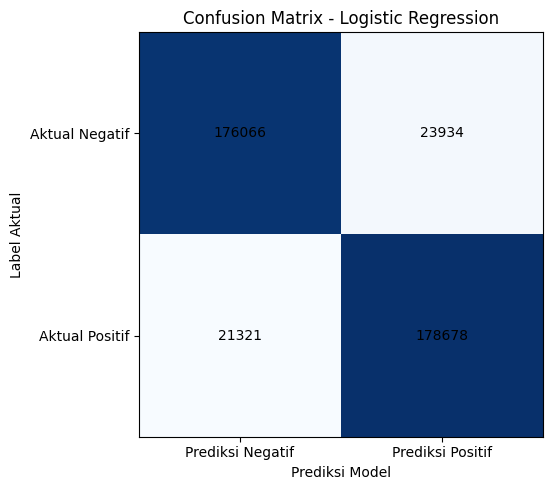

Confusion matrix disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\figures\confusion_matrix_logistic_regression.png


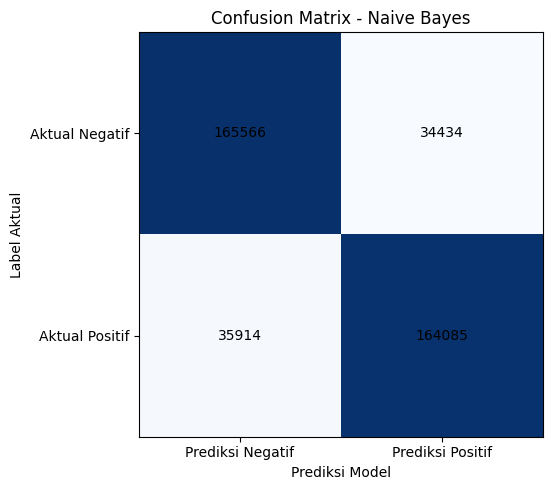

Confusion matrix disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\figures\confusion_matrix_naive_bayes.png


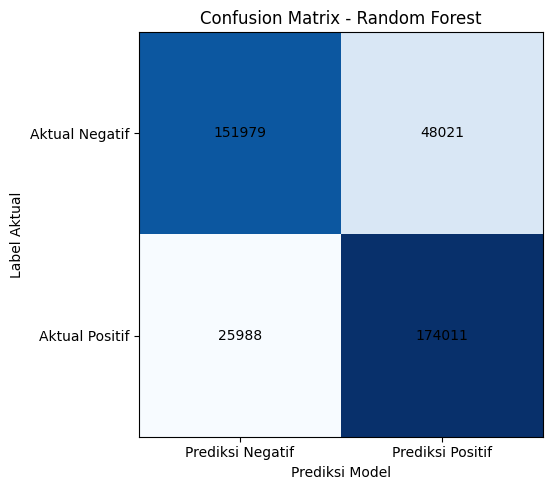

Confusion matrix disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\figures\confusion_matrix_random_forest.png


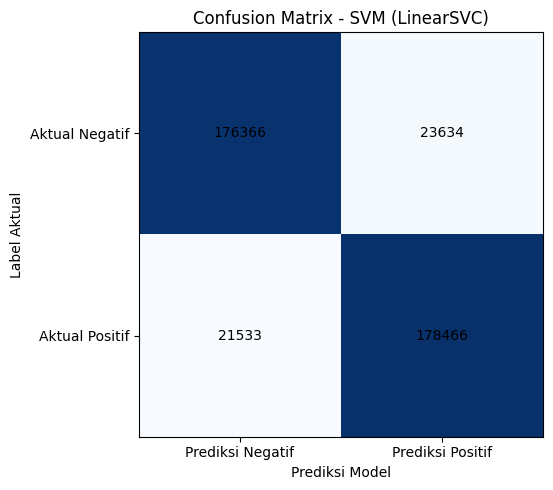

Confusion matrix disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\figures\confusion_matrix_svm_(linearsvc).png


In [21]:
def plot_confusion_matrix(predictions, model_name, output_dir):
    confusion_df = predictions.groupBy("label", "prediction").count().toPandas()
    confusion_df = confusion_df.sort_values(["label", "prediction"]).reset_index(drop=True)

    confusion_matrix = confusion_df.pivot(
        index="label", columns="prediction", values="count"
    ).fillna(0)

    plt.figure(figsize=(6, 5))
    plt.imshow(confusion_matrix.values, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prediksi Model")
    plt.ylabel("Label Aktual")
    plt.xticks([0, 1], ["Prediksi Negatif", "Prediksi Positif"])
    plt.yticks([0, 1], ["Aktual Negatif", "Aktual Positif"])

    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            plt.text(j, i, int(confusion_matrix.values[i, j]), ha="center", va="center")

    plt.tight_layout()
    save_path = output_dir / f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Confusion matrix disimpan ke: {save_path}")
    return confusion_matrix

# Jalankan untuk semua model
for model_name, (preds, _) in model_predictions.items():
    cm = plot_confusion_matrix(preds, model_name, OUTPUT_FIGURES_DIR)

## 15. Menyimpan Hasil Evaluasi

Metrik evaluasi dan confusion matrix disimpan ke folder `outputs/metrics`.

In [22]:
metrics_path = OUTPUT_METRICS_DIR / "all_models_metrics.csv"
comparison_df.to_csv(metrics_path, index=False)

print("Metrik semua model disimpan ke:", metrics_path)

Metrik semua model disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\metrics\all_models_metrics.csv


## 16. Visualisasi Metrik Evaluasi

Grafik berikut menunjukkan nilai accuracy, precision, recall, dan F1-score.

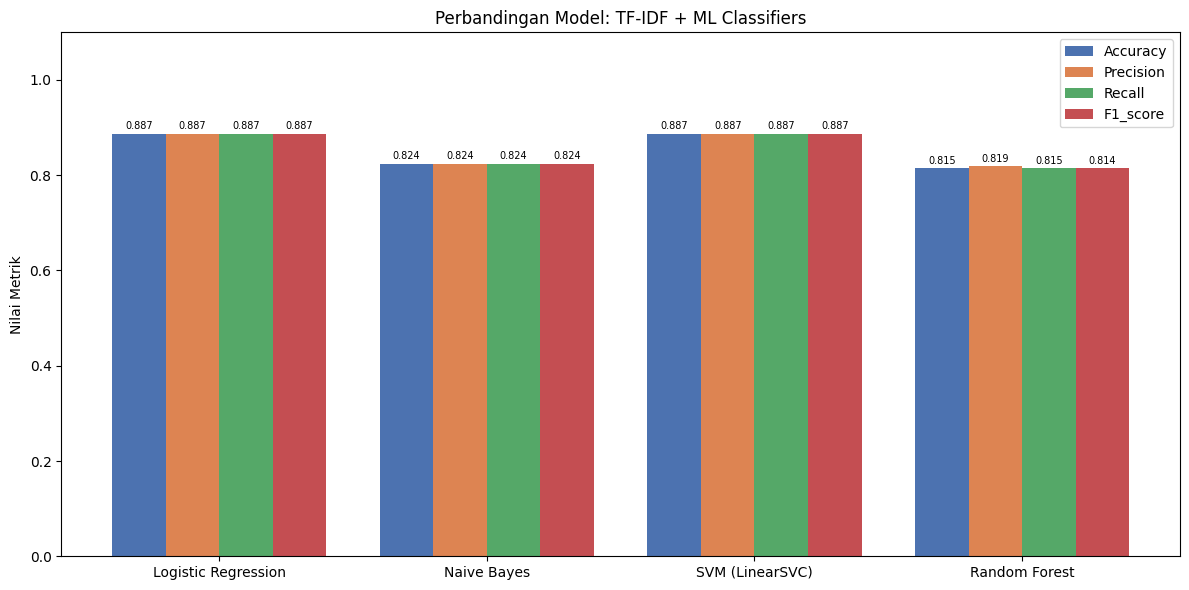

Grafik perbandingan model disimpan ke: d:\File Guweh\Kuliah\Semester 6\Big Data dan AI\TUBES AKHIR\Amazon-Reviews-for-Sentiment-Analysis\outputs\figures\model_comparison.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

x      = range(len(comparison_df))
width  = 0.2
metrics = ["accuracy", "precision", "recall", "f1_score"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    positions = [pos + i * width for pos in x]
    bars = ax.bar(positions, comparison_df[metric], width, label=metric.capitalize(), color=color)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7
        )

ax.set_xticks([pos + 1.5 * width for pos in x])
ax.set_xticklabels(comparison_df["model"])
ax.set_ylim(0, 1.1)
ax.set_title("Perbandingan Model: TF-IDF + ML Classifiers")
ax.set_ylabel("Nilai Metrik")
ax.legend()
plt.tight_layout()

comparison_fig_path = OUTPUT_FIGURES_DIR / "model_comparison.png"
plt.savefig(comparison_fig_path, dpi=300)
plt.show()

print("Grafik perbandingan model disimpan ke:", comparison_fig_path)

## 17. Visualisasi Confusion Matrix

Visualisasi berikut menunjukkan jumlah prediksi benar dan salah untuk kelas negatif dan positif.

In [24]:
# Verifikasi file confusion matrix yang sudah disimpan
import os

print("File confusion matrix yang tersimpan:")
for f in sorted(OUTPUT_FIGURES_DIR.iterdir()):
    if "confusion" in f.name:
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

File confusion matrix yang tersimpan:
  confusion_matrix_logistic_regression.png  (73.5 KB)
  confusion_matrix_naive_bayes.png  (72.3 KB)
  confusion_matrix_random_forest.png  (72.5 KB)
  confusion_matrix_svm_(linearsvc).png  (75.9 KB)


## 18. Ringkasan Hasil

Bagian ini mencetak ringkasan hasil utama yang dapat digunakan sebagai bahan laporan.

In [25]:
print("Ringkasan Evaluasi Semua Model")
print("=" * 50)
print(comparison_df.to_string(index=False))
print()

best_model = comparison_df.loc[comparison_df["f1_score"].idxmax()]
print(f"Model terbaik berdasarkan F1-score: {best_model['model']}")
print(f"  Accuracy : {best_model['accuracy']:.4f}")
print(f"  Precision: {best_model['precision']:.4f}")
print(f"  Recall   : {best_model['recall']:.4f}")
print(f"  F1-score : {best_model['f1_score']:.4f}")

Ringkasan Evaluasi Semua Model
              model  accuracy  precision  recall  f1_score
Logistic Regression    0.8869     0.8869  0.8869    0.8869
        Naive Bayes    0.8241     0.8241  0.8241    0.8241
    SVM (LinearSVC)    0.8871     0.8871  0.8871    0.8871
      Random Forest    0.8150     0.8188  0.8150    0.8144

Model terbaik berdasarkan F1-score: SVM (LinearSVC)
  Accuracy : 0.8871
  Precision: 0.8871
  Recall   : 0.8871
  F1-score : 0.8871


## 19. Penutup

Notebook ini telah menyelesaikan pipeline utama:

1. Membaca dataset besar menggunakan PySpark.
2. Membersihkan teks review.
3. Menyimpan data bersih ke Parquet.
4. Melakukan tokenization dan stopword removal.
5. Mengubah teks menjadi fitur TF-IDF.
6. Melatih dan membandingkan empat model: Logistic Regression, Naive Bayes, SVM (LinearSVC), dan Random Forest.
7. Mengevaluasi model menggunakan beberapa metrik.
8. Menyimpan hasil evaluasi dan visualisasi.

Langkah berikutnya untuk pengembangan proyek:

- Menyusun laporan final 10–15 halaman berdasarkan hasil notebook.